# Bodrum Hotel & Destination Intelligence
## 06 - Resmî Otel Özellikleri Eşleştirme ve Audit

Bu notebookun amacı **analiz yapmak değil**, resmî Bodrum konaklama tesisi kayıtlarını mevcut
192 otelik proje master verisine güvenilir biçimde bağlamak ve zenginleştirilmiş bir otel
dataseti üretmektir.

İki farklı evren var:

- **A — proje otelleri**: `data/processed/hotels_features.csv`, ~192 benzersiz otel (Google
  Places kaynaklı).
- **B — resmî tesis kayıtları**: `data/external/hotel/hotel_attributes_official_bodrum.csv`,
  ~168 resmî işletme belgeli tesis (Muğla İl Kültür ve Turizm Müdürlüğü kaynaklı).

**Bu iki dataset birebir aynı listeyi temsil etmek zorunda değildir.** 168 resmî tesis, 192
otelin tamamı anlamına gelmez; eşleşmeyen kayıtların olması normaldir ve beklenmektedir.

Temel ilke:

> **Yanlış eşleştirmeden kaçının. Daha az ama güvenilir eşleşme, çok sayıda hatalı
> eşleşmeden daha değerlidir.**

Bu nedenle yalnızca `MATCHED_HIGH_CONFIDENCE` olarak sınıflandırılan eşleşmeler otomatik olarak
zenginleştirilmiş datasete işlenir; şüpheli her şey ayrı bir manuel inceleme tablosuna yazılır.

Bu notebookta **kesinlikle yapılmayanlar**: K-Means/PCA/DBSCAN, regresyon/sınıflandırma,
rating/fiyat tahmini, sentiment/NLP, öneri sistemi, anomali tespiti, web scraping. Ayrıca
`data/processed/hotels_features.csv` ve external CSV hiçbir noktada değiştirilmez;
zenginleştirilmiş çıktı ayrı bir dosyaya (`data/processed/hotels_enriched.csv`) yazılır.


### 1. Kurulum ve veri yükleme

Eşleştirme mantığı `src/bodrum_intelligence/hotel_matching.py` modülünde tutulur (normalizasyon,
aday üretimi, skorlama, sınıflandırma, zenginleştirme fonksiyonları); notebook yalnızca bu
fonksiyonları çağırır ve sonuçları yorumlar.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.hotel_matching import (
    MatchThresholds,
    build_area_coverage,
    build_best_match_table,
    build_enriched_dataset,
    classify_match,
    derive_official_status,
    detect_official_duplicates,
    explain_review_reason,
    generate_candidates,
    prepare_official_normalization,
    prepare_project_normalization,
    save_matching_outputs,
    score_match,
)

PROJECT_HOTELS_PATH = PROJECT_ROOT / "data" / "processed" / "hotels_features.csv"
OFFICIAL_PATH = PROJECT_ROOT / "data" / "external" / "hotel" / "hotel_attributes_official_bodrum.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

assert PROJECT_HOTELS_PATH.exists(), f"Proje otel verisi bulunamadı: {PROJECT_HOTELS_PATH}"
assert OFFICIAL_PATH.exists(), f"Resmî tesis verisi bulunamadı: {OFFICIAL_PATH}"

project_df = pd.read_csv(PROJECT_HOTELS_PATH, dtype={"phone": "string"})
official_df = pd.read_csv(OFFICIAL_PATH)

print(f"Proje otelleri (A): {project_df.shape[0]} satır, {project_df.shape[1]} kolon")
print(f"Resmî tesisler (B): {official_df.shape[0]} satır, {official_df.shape[1]} kolon")

Proje otelleri (A): 192 satır, 34 kolon
Resmî tesisler (B): 168 satır, 14 kolon


### 2. Proje otelleri audit (evren A)

Eşleştirmeye başlamadan önce her iki tablo ayrı ayrı denetlenir. Bu, `02_data_audit.ipynb`'i
tekrarlamaz; yalnızca eşleştirmeyi doğrudan etkileyecek alanlara (kimlik, isim, telefon, bölge)
odaklanır.


In [2]:
def normalized_name_duplicate_count(names, normalize_fn):
    normalized = names.map(normalize_fn)
    return int(normalized[normalized.notna()].duplicated().sum())


from bodrum_intelligence.hotel_matching import normalize_text

project_audit = pd.DataFrame(
    [
        ("row_count", len(project_df)),
        ("column_count", project_df.shape[1]),
        ("unique_hotel_id", project_df["hotel_id"].nunique()),
        ("duplicate_hotel_id", int(project_df["hotel_id"].duplicated().sum())),
        ("unique_place_id", project_df["place_id"].nunique()),
        ("duplicate_place_id", int(project_df["place_id"].duplicated().sum())),
        ("missing_hotel_name", int(project_df["hotel_name"].isna().sum())),
        ("missing_phone", int(project_df["phone"].isna().sum())),
        ("missing_area", int(project_df["area"].isna().sum())),
        ("duplicate_normalized_hotel_name", normalized_name_duplicate_count(project_df["hotel_name"], normalize_text)),
    ],
    columns=["metric", "value"],
)
display(project_audit)

,metric,value
0,row_count,192
1,column_count,34
2,unique_hotel_id,192
3,duplicate_hotel_id,0
4,unique_place_id,192
5,duplicate_place_id,0
6,missing_hotel_name,0
7,missing_phone,4
8,missing_area,0
9,duplicate_normalized_hotel_name,0


**Bulgu:** Kimlikler (`hotel_id`, `place_id`) beklendiği gibi tamamen benzersiz; isim, telefon
ve bölge eksikliği sınırlı (bkz. `02_data_audit.ipynb`'te daha önce belgelenen 4 eksik telefon).
Normalize edilmiş isimde tekrar eden kayıt yok — proje tarafında eşleştirmeyi zorlaştıracak bir
duplicate isim problemi bulunmuyor.

### 3. Resmî tesisler audit (evren B)

Aynı temel denetim resmî tabloya uygulanır; ayrıca yıldız/oda/yatak/tip dağılımı ve
`mapped_project_area` kapsamı ile açık mantık hataları (`official_star_rating` 1-5 dışında,
`room_count`/`bed_count` <= 0, `bed_count < room_count`, duplicate `official_facility_id`)
kontrol edilir. **Hiçbir değer otomatik düzeltilmez, yalnızca flag üretilir.**


In [3]:
official_audit = pd.DataFrame(
    [
        ("row_count", len(official_df)),
        ("column_count", official_df.shape[1]),
        ("unique_official_facility_id", official_df["official_facility_id"].nunique()),
        ("duplicate_official_facility_id", int(official_df["official_facility_id"].duplicated().sum())),
        ("missing_official_name", int(official_df["official_name"].isna().sum())),
        ("missing_official_phone", int(official_df["official_phone"].isna().sum())),
        ("missing_official_address_area", int(official_df["official_address_area"].isna().sum())),
        ("missing_mapped_project_area", int(official_df["mapped_project_area"].isna().sum())),
        ("duplicate_normalized_official_name", normalized_name_duplicate_count(official_df["official_name"], normalize_text)),
    ],
    columns=["metric", "value"],
)
display(official_audit)

,metric,value
0,row_count,168
1,column_count,14
2,unique_official_facility_id,168
3,duplicate_official_facility_id,0
4,missing_official_name,0
5,missing_official_phone,16
6,missing_official_address_area,1
7,missing_mapped_project_area,13
8,duplicate_normalized_official_name,1


In [4]:
print("official_star_rating dağılımı:")
display(official_df["official_star_rating"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\nofficial_type dağılımı:")
display(official_df["official_type"].value_counts(dropna=False).to_frame("count"))

print("\nroom_count / bed_count özet:")
display(official_df[["room_count", "bed_count"]].describe().loc[["min", "50%", "max"]])

print("\nmapped_project_area kapsamı:")
display(official_df["area_mapping_confidence"].value_counts(dropna=False).to_frame("count"))
print(f"mapped_project_area eksik: {official_df['mapped_project_area'].isna().sum()} / {len(official_df)}")

official_star_rating dağılımı:


,count
official_star_rating,
1.0,3
2.0,15
3.0,29
4.0,37
5.0,44
NaN,40



official_type dağılımı:


,count
official_type,
5 YILDIZLI OTEL,33
4 YILDIZLI OTEL,33
3 YILDIZLI OTEL,29
BUTİK OTEL,18
2 YILDIZLI OTEL,15
MÜSTAKİL APART,12
5 YILDIZLI T.K.,10
PANSİYON,3
1 YILDIZLI OTEL,3



room_count / bed_count özet:


,room_count,bed_count
min,6.0,12.0
50%,77.0,168.0
max,882.0,2060.0



mapped_project_area kapsamı:


,count
area_mapping_confidence,
high,151
NaN,13
medium,4


mapped_project_area eksik: 13 / 168


In [5]:
logic_error_checks = pd.DataFrame(
    [
        ("official_star_rating < 1", int((official_df["official_star_rating"] < 1).sum())),
        ("official_star_rating > 5", int((official_df["official_star_rating"] > 5).sum())),
        ("room_count <= 0", int((official_df["room_count"] <= 0).sum())),
        ("bed_count <= 0", int((official_df["bed_count"] <= 0).sum())),
        ("bed_count < room_count", int((official_df["bed_count"] < official_df["room_count"]).sum())),
        ("duplicate official_facility_id", int(official_df["official_facility_id"].duplicated().sum())),
    ],
    columns=["check", "issue_count"],
)
display(logic_error_checks)
assert logic_error_checks["issue_count"].eq(0).all(), "Resmî veri setinde ham mantık hatası bulundu; düzeltilmeden ilerlenmemeli." 

,check,issue_count
0,official_star_rating < 1,0
1,official_star_rating > 5,0
2,room_count <= 0,0
3,bed_count <= 0,0
4,bed_count < room_count,0
5,duplicate official_facility_id,0


**Bulgu:** `official_facility_id` benzersiz (168/168), temel aralık/mantık kontrollerinin
tamamı temiz (0 ihlal). `official_star_rating` 40/168 kayıtta eksik — bu, veri toplama notunda
("Never infer a star rating where the official type does not explicitly encode one") açıklandığı
gibi kasıtlı bir eksikliktir (`BUTİK OTEL`, `MÜSTAKİL APART`, `PANSİYON` gibi tipler yıldız
belirtmez); **tahmin edilmez, olduğu gibi bırakılır**. `mapped_project_area`, 13 kayıtta eksik
(bu kayıtlar eşleştirmede bölge sinyali olmadan, yalnızca isim/telefon/adresle değerlendirilir).

### 4. Resmî tesis içinde olası duplicate / çelişki tespiti

Aynı tesisin resmî listede birden fazla satırı olabilir (aynı/çok benzer isim, aynı telefon).
`detect_official_duplicates`, bu şekilde gruplanan kayıtları `official_duplicate_candidate`
olarak işaretler; grup içinde yıldız/tip/oda/yatak değerleri **çelişiyorsa** ayrıca
`official_conflict_flag=True` olur. **Hiçbir satır otomatik olarak seçilmez veya silinmez.**


In [6]:
official_norm = prepare_official_normalization(official_df)
official_norm = detect_official_duplicates(official_norm)

print(f"official_duplicate_candidate: {int(official_norm['official_duplicate_candidate'].sum())}")
print(f"official_conflict_flag: {int(official_norm['official_conflict_flag'].sum())}")

conflict_columns = [
    "duplicate_group_id", "official_facility_id", "official_name", "official_type",
    "official_star_rating", "room_count", "bed_count", "official_address_area", "official_phone",
    "official_duplicate_candidate", "official_conflict_flag", "conflict_reason",
]
official_conflicts = official_norm.loc[
    official_norm["official_duplicate_candidate"], conflict_columns
].sort_values(["duplicate_group_id", "official_facility_id"])
display(official_conflicts)

official_duplicate_candidate: 8
official_conflict_flag: 8


,duplicate_group_id,official_facility_id,official_name,official_type,official_star_rating,room_count,bed_count,official_address_area,official_phone,official_duplicate_candidate,official_conflict_flag,conflict_reason
24,1,OFFBOD025,DOUBLETREE BY HİLTON BODRUM MARİNA VİST,A5 YILDIZLI OTEL,5.0,87.0,176.0,ESKİÇEŞME MAH.,0252 316 2269,True,True,"Farklı değerler: official_star_rating, officia..."
63,1,OFFBOD064,DOUBLETREE BY HİLTON BODRUM MARİNA VİST,A4 YILDIZLI OTEL,4.0,87.0,176.0,ESKİÇEŞME MAH.,0252 316 2269,True,True,"Farklı değerler: official_star_rating, officia..."
46,3,OFFBOD047,VOYAGE BODRUM,5 YILDIZLI OTEL,5.0,150.0,300.0,ESKİÇEŞME MAH.,0252 316 4443,True,True,"Farklı değerler: official_star_rating, officia..."
79,3,OFFBOD080,VOYAGE BODRUM PRIVATE,4 YILDIZLI OTEL,4.0,26.0,52.0,ESKİÇEŞME MAH.,0252 316 4443,True,True,"Farklı değerler: official_star_rating, officia..."
60,4,OFFBOD061,CHARM BEACH HOTEL,4 YILDIZLI OTEL,4.0,112.0,236.0,TURGUTREİS MAH.,0252 319 5550,True,True,"Farklı değerler: room_count, bed_count"
73,4,OFFBOD074,PARKIM AYAZ OTEL,4 YILDIZLI OTEL,4.0,237.0,474.0,GÜMBET MAHALLESİ,0252 319 5550,True,True,"Farklı değerler: room_count, bed_count"
57,5,OFFBOD058,CACTUS FLEUR BEACH CLUB,4 YILDIZLI OTEL,4.0,137.0,328.0,YALIKAVAK MAH.,0252 385 3717,True,True,"Farklı değerler: official_type, room_count, be..."
151,5,OFFBOD152,ELEMENTA BY CACTUS HOTELS,BUTİK OTEL,NaN,52.0,111.0,YALIKAVAK MAH.,0252 385 3717,True,True,"Farklı değerler: official_type, room_count, be..."


**Bulgu:** 4 grup (8 kayıt) aynı telefon ve/veya aynı normalize isim nedeniyle
`duplicate_candidate` olarak işaretlendi; bunların tamamı aynı zamanda `conflict_flag=True`
(yıldız/tip/oda/yatak değerleri grup içinde farklı). İncelemede iki farklı gerçek senaryo
görülüyor: (1) gerçek veri tekrarı (OFFBOD025/OFFBOD064 — aynı isim, aynı bölge, aynı telefon)
ve (2) muhtemelen aynı işletme grubuna ait **kardeş tesisler** aynı santral numarasını
paylaşıyor (ör. "VOYAGE BODRUM" / "VOYAGE BODRUM PRIVATE", "CACTUS FLEUR BEACH CLUB" /
"ELEMENTA BY CACTUS HOTELS"). Her iki durumda da otomatik seçim yapılmadı; tam liste
`reports/hotel_attributes_official_conflicts.csv` dosyasına yazılacak (Bölüm 15).

### 5. Eşleştirme için normalizasyon

Ham `hotel_name`/`official_name`/`phone`/`address` kolonları **değiştirilmez**. Yalnızca
eşleştirme amaçlı geçici kolonlar üretilir:

- `*_normalized_full`: küçük harf, kontrollü Türkçe karakter dönüşümü (ı/İ→i, ğ→g, ü→u, ş→s,
  ö→o, ç→c), noktalama temizliği, fazla boşluk temizliği. **Hiçbir kelime silinmez** — `hotel`,
  `otel`, `resort`, `spa` gibi kelimeler bazı otelleri ayırt etmek için gerekli olabileceğinden
  körlemesine kaldırılmaz.
- `*_normalized_core`: `full` üzerine yalnızca coğrafi/dolgu kelimeler (`bodrum`, `turkey`,
  `turkiye`) kaldırılır — bu kelimeler veri setinin tamamında ortak olduğu için ayırt edici
  değer taşımaz. `hotel`/`otel`/`resort`/`spa` `core` sürümde de dokunulmadan kalır.
- `phone_normalized`: yalnızca rakamlar, son 10 hane (ülke kodu/başındaki 0 farkı ortadan
  kalkar).
- `address_normalized` / `area_normalized`: aynı metin normalizasyonu.


In [7]:
project_norm = prepare_project_normalization(project_df)
# official_norm, Bölüm 4'te duplicate/conflict flag'leriyle birlikte zaten üretildi; burada
# yeniden kullanılıyor (normalize kolonları o adımda eklenmişti).

sample_cols_project = ["hotel_name", "hotel_name_normalized_full", "hotel_name_normalized_core", "phone", "phone_normalized"]
display(project_norm[sample_cols_project].head(8))

sample_cols_official = ["official_name", "official_name_normalized_full", "official_name_normalized_core", "official_phone", "official_phone_normalized"]
display(official_norm[sample_cols_official].head(8))

,hotel_name,hotel_name_normalized_full,hotel_name_normalized_core,phone,phone_normalized
0,Aksoy Taş Ev,aksoy tas ev,aksoy tas ev,+905414124141,5414124141
1,Armonia Holiday Village & Spa,armonia holiday village spa,armonia holiday village spa,+902529991303,2529991303
2,ASPAT HOTEL BODRUM Beach Restaurant,aspat hotel bodrum beach restaurant,aspat hotel beach restaurant,+905308656175,5308656175
3,Bendis Beach Hotel,bendis beach hotel,bendis beach hotel,+902523210924,2523210924
4,ByAkkan,byakkan,byakkan,+905324996884,5324996884
5,Club Marma Hotel,club marma hotel,club marma hotel,+902526060333,2526060333
6,Kefaluka Resort,kefaluka resort,kefaluka resort,+902523110390,2523110390
7,LA BREZZA SUITE &HOTEL,la brezza suite hotel,la brezza suite hotel,+905352077422,5352077422


,official_name,official_name_normalized_full,official_name_normalized_core,official_phone,official_phone_normalized
0,ANADOLU HOLIDAY VILLAGE,anadolu holiday village,anadolu holiday village,0252 319 7171,2523197171
1,ARMONIA HOLIDAY VILLAGE & SPA,armonia holiday village spa,armonia holiday village spa,0252 393 6315,2523936315
2,BODRUM PARK RESORT,bodrum park resort,park resort,0252 368 9020,2523689020
3,BODRUM LOFT,bodrum loft,loft,0312 408 1000,3124081000
4,CLUB LALUNA,club laluna,club laluna,0252 319 2555,2523192555
5,CLUB MÜSKEBİ,club muskebi,club muskebi,0252 358 57 87,2523585787
6,CLUB MED PALMİYE TATİL KÖYÜ - ANIK TAT,club med palmiye tatil koyu anik tat,club med palmiye tatil koyu anik tat,0252 368 9152,2523689152
7,ERSAN TATİLKÖYÜ,ersan tatilkoyu,ersan tatilkoyu,0252 316 8980,2523168980


**Örnek:** "Mandarin Oriental, Bodrum" → `full`="mandarin oriental bodrum", `core`="mandarin
oriental" (yalnızca "bodrum" düşer). Resmî kayıt "MANDARİN ORIENTAL BODRUM" da aynı `core`
değerine indirgeniyor — bu, aşağıdaki Katman 2'de doğrudan kesin eşleşme sağlıyor.

### 6. Katmanlı eşleştirme adayları

`generate_candidates`, her proje oteli için üç katmanda aday resmî tesis toplar:

1. **Telefon** — normalize telefon birebir aynıysa.
2. **Kesin çekirdek isim** — `hotel_name_normalized_core` birebir aynıysa.
3. **Fuzzy isim** — `difflib.SequenceMatcher` oranı ≥ 0.55 olan tüm resmî kayıtlar (hem `full`
   hem `core` üzerinden en yüksek oran alınır).

Üç katmanın adayları birleştirilir (tekilleştirilir); tek başına fuzzy skor kullanılmaz —
her aday için isim benzerliğine ek olarak bölge, telefon ve adres destek sinyalleri de
hesaplanır (Bölüm 7).


In [8]:
candidates = generate_candidates(project_norm, official_norm)

candidate_summary = pd.DataFrame(
    [
        ("total_candidate_pairs", len(candidates)),
        ("project_hotels_with_at_least_one_candidate", candidates["hotel_id"].nunique()),
        ("project_hotels_with_zero_candidates", project_df["hotel_id"].nunique() - candidates["hotel_id"].nunique()),
        ("median_candidates_per_hotel", int(candidates.groupby("hotel_id").size().median())),
    ],
    columns=["metric", "value"],
)
display(candidate_summary)

,metric,value
0,total_candidate_pairs,2129
1,project_hotels_with_at_least_one_candidate,168
2,project_hotels_with_zero_candidates,24
3,median_candidates_per_hotel,8


**Bulgu:** 192 proje otelinin 168'i için en az bir aday bulundu; 24 otel için (rakam sayısal
sonuçtan üretilir) hiçbir katman minimum fuzzy eşiğini bile geçen bir resmî kayıt üretemedi —
bu oteller doğrudan `UNMATCHED` olacak (Bölüm 8), herhangi bir zorlama yapılmaz.

### 7. Açıklanabilir match score

Her aday çift için dört ham sinyal hesaplanır: `name_similarity`, `area_match`, `phone_match`,
`address_similarity`. Ağırlıklı skor:

```
match_score = 0.60 * name_similarity + 0.20 * phone_match + 0.15 * area_match + 0.05 * address_similarity
```

`area_match` resmî tarafta bölge bilgisi yoksa (`None`) ne ödüllendirilir ne cezalandırılır
(0.5 nötr katkı). **Kesin ve tekil telefon eşleşmesi** tek başına güçlü bir sinyal olduğu için
skoru en az 0.95'e yükseltir (isimler farklı yazılmış olsa bile aynı santral numarasını
paylaşma ihtimali yüksektir).


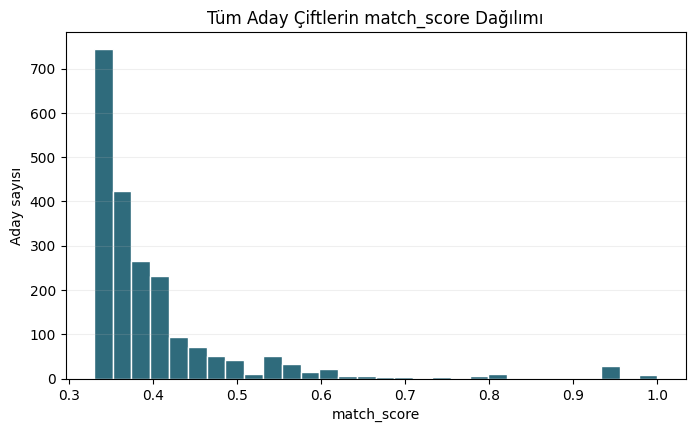

En iyi adaya göre (her otel için tek en yüksek skor) skor dağılımı:


count    168.000000
mean       0.638445
std        0.212449
min        0.330000
25%        0.473650
50%        0.588200
75%        0.800000
max        1.000000
Name: match_score, dtype: float64

In [9]:
candidates["match_score"] = [
    score_match(row.name_similarity, row.area_match, row.phone_match, row.address_similarity)
    for row in candidates.itertuples()
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(candidates["match_score"], bins=30, color="#2F6B7C", edgecolor="white")
ax.set(title="Tüm Aday Çiftlerin match_score Dağılımı", xlabel="match_score", ylabel="Aday sayısı")
ax.grid(axis="y", alpha=0.2)
plt.show()

print("En iyi adaya göre (her otel için tek en yüksek skor) skor dağılımı:")
best_per_hotel_preview = candidates.sort_values(["hotel_id", "match_score"], ascending=[True, False]).groupby("hotel_id").first()
display(best_per_hotel_preview["match_score"].describe())

**Bulgu — skor dağılımı:** Telefon eşleşen adaylar skoru doğrudan ≥0.95 bandına taşıyor; telefon
olmadan ulaşılabilecek matematiksel tavan 0.60+0.15+0.05=0.80'dir (isim %60 + bölge %15 + adres
%5 tam puan alsa bile). Bu, **0.80 ile 0.95 arasında doğal ve boş bir bölge** oluşturuyor — bu
notebookta yüksek güven eşiği bu boşluğa değil, doğrudan bileşenlere (isim ≥0.95 **ve** bölge
doğrulanmış) dayandırıldı; aşağıda gerçek sınır vakalarıyla gösteriliyor.


In [10]:
edge_case_ids = ["Armonia Holiday Village & Spa", "Mandarin Resort Hotel", "Mandarin Oriental, Bodrum", "Voyage Torba", "Voyage Torba Private"]
edge_case_cols = ["hotel_name", "official_name", "name_similarity", "area_match", "phone_match", "address_similarity", "match_score"]
edge_cases = candidates[candidates["hotel_name"].isin(edge_case_ids)].sort_values(["hotel_name", "match_score"], ascending=[True, False])
edge_cases = edge_cases.loc[edge_cases.groupby("hotel_name")["match_score"].idxmax()]
display(edge_cases[edge_case_cols])

,hotel_name,official_name,name_similarity,area_match,phone_match,address_similarity,match_score
1,Armonia Holiday Village & Spa,ARMONIA HOLIDAY VILLAGE & SPA,1.0000,False,False,1.0,0.65
628,"Mandarin Oriental, Bodrum",MANDARİN ORIENTAL BODRUM,1.0000,True,False,1.0,0.80
491,Mandarin Resort Hotel,MANDARİN ORIENTAL BODRUM,0.6842,False,True,0.0,0.95
1889,Voyage Torba,VOYAGE TORBA,1.0000,True,True,1.0,1.00
1892,Voyage Torba Private,VOYAGE TORBA,0.7500,True,True,1.0,0.95


**Sınır vakaları (dataset'ten gerçek örnekler):**

- **"Armonia Holiday Village & Spa"**: isim %100, adres %100 örtüşüyor ama resmî kayıt bölgeyi
  "Turgutreis" olarak işaretlerken proje bu oteli "Akyarlar"a koyuyor — **açık bir bölge
  çelişkisi**. İsim/adres ne kadar mükemmel olursa olsun bu otomatik yüksek güvene alınmadı;
  `REVIEW_REQUIRED`'a düşürüldü (bkz. Bölüm 8, `classify_match`).
- **"Mandarin Resort Hotel" vs "Mandarin Oriental, Bodrum"**: iki farklı proje oteli, resmî
  kayıttaki **aynı telefon numarasına** eşleşiyor (muhtemelen Google verisinde bir veri
  girişi/karışıklık hatası). Yalnızca isim benzerliği %68 olan "Mandarin Resort Hotel" ham
  telefon eşleşmesiyle skorunu 0.95'e taşısa da, isim benzerliği %100 olan "Mandarin Oriental,
  Bodrum" ile çakışınca çakışma çözümü **isim benzerliği daha yüksek olanı** tutuyor (Bölüm 8);
  "Mandarin Resort Hotel" otomatik bağlanmak yerine manuel incelemeye düşüyor.
- **"Voyage Torba" / "Voyage Torba Private"**: kardeş tesisler aynı resepsiyon telefonunu
  paylaşıyor. Ana tesisle isim benzerliği %100 olan "Voyage Torba" yüksek güvenle eşleşirken,
  resmî listede kendi ayrı kaydı olmayan "Voyage Torba Private" aynı `official_facility_id`'yi
  otomatik olarak devralmıyor; manuel incelemeye düşüyor.

Bu üç örnek, tek bir sinyale (yalnızca isim veya yalnızca telefon) güvenmenin neden yeterli
olmadığını somut biçimde gösteriyor.

### 8. Match statüsü sınıflandırması

`classify_match`, her proje oteli için en iyi tek adayı `MATCHED_HIGH_CONFIDENCE` /
`REVIEW_REQUIRED` / `UNMATCHED` olarak sınıflandırır. Yüksek güven için **iki** konservatif yol
vardır:

1. Kesin ve **tekil** telefon eşleşmesi (aynı telefon birden fazla resmî tesiste geçiyorsa bu
   yol devre dışı kalır — Bölüm 3'te bulunan 4 paylaşılan telefon grubu böyle ele alınıyor).
2. İsim benzerliği ≥ 0.95 **ve** bölge açıkça doğrulanmış (`area_match is True`; bölge bilgisi
   eksik veya çelişkiliyse bu yol tetiklenmez — Bölüm 7'deki Armonia örneği tam olarak bunu
   gösteriyor).

Ayrıca aynı `official_facility_id`'nin iki farklı otele yüksek güvenle bağlanması (Bölüm 7'deki
Mandarin örneği) otomatik olarak tespit edilip yalnızca isim benzerliği daha yüksek olan taraf
tutulur; diğeri `REVIEW_REQUIRED`'a düşürülür.


,hotel_count
match_status,
UNMATCHED,92
MATCHED_HIGH_CONFIDENCE,52
REVIEW_REQUIRED,48


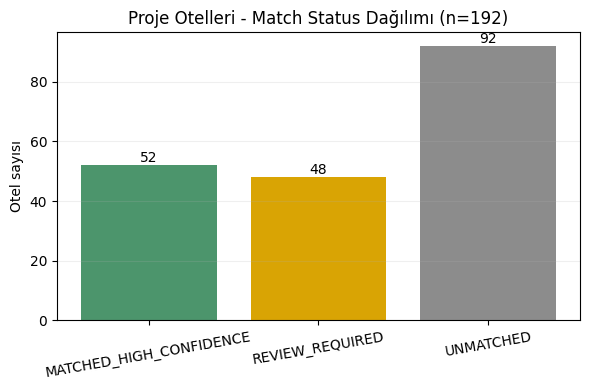

In [11]:
best_matches = build_best_match_table(candidates, project_norm)
assert len(best_matches) == len(project_df), "Her proje oteli için tam olarak bir satır olmalı."
assert best_matches["hotel_id"].nunique() == len(project_df)

status_counts = best_matches["match_status"].value_counts()
display(status_counts.to_frame("hotel_count"))

fig, ax = plt.subplots(figsize=(6, 4))
order = ["MATCHED_HIGH_CONFIDENCE", "REVIEW_REQUIRED", "UNMATCHED"]
colors = {"MATCHED_HIGH_CONFIDENCE": "#4C956C", "REVIEW_REQUIRED": "#D9A404", "UNMATCHED": "#8C8C8C"}
values = [int(status_counts.get(s, 0)) for s in order]
ax.bar(order, values, color=[colors[s] for s in order])
ax.set(title="Proje Otelleri - Match Status Dağılımı (n=192)", ylabel="Otel sayısı")
ax.grid(axis="y", alpha=0.2)
for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Bulgu:** 192 proje otelinden yalnızca telefon veya isim+bölge ile **çok güçlü** doğrulanan
kayıtlar otomatik olarak yüksek güvene alındı; geri kalanı ya insan incelemesi bekliyor ya da
hiç aday bulunamadığı için eşleşmedi. Tam sayılar Bölüm 19'da özetlenecek.

### 9. Resmî tesis tarafında statü

Her resmî kayıt için de bir statü türetilir: `MATCHED` (bir proje oteline yüksek güvenle
bağlandı), `CONFLICT` (Bölüm 4'te iç çelişki bulundu — veri kalitesi sorunu önceliklidir, bir
eşleşmesi olsa bile gizlenmez) veya `UNMATCHED_OFFICIAL` (proje örnekleminde karşılığı
bulunamadı).


In [12]:
official_status = derive_official_status(official_norm, best_matches)
display(official_status["official_match_status"].value_counts().to_frame("facility_count"))

,facility_count
official_match_status,
UNMATCHED_OFFICIAL,108
MATCHED,52
CONFLICT,8


**Bulgu:** 168 resmî kaydın bir kısmı bizim 192 otelik örneklemimizde hiç yer almıyor
(`UNMATCHED_OFFICIAL`) — bu beklenen bir durumdur, çünkü resmî liste yalnızca "işletme belgeli"
tesisleri kapsar ve bizim Google Places kaynaklı örneklemimiz daha geniş bir konaklama
yelpazesini (apart, pansiyon, küçük butik) içerir. `CONFLICT` olarak işaretlenen 8 kayıt, bir
eşleşmeye sahip olsalar bile ayrı olarak raporlanacak (Bölüm 15) — çelişkili veri, eşleşme
başarısıyla gizlenmez.

### 10. High confidence match tablosu

Yalnızca `MATCHED_HIGH_CONFIDENCE` kayıtlar; bu tablo Bölüm 13'teki zenginleştirilmiş
datasetin temelini oluşturur.


In [13]:
high_confidence_cols = [
    "hotel_id", "hotel_name", "official_facility_id", "official_name",
    "match_score", "match_method", "official_type", "official_star_rating", "room_count", "bed_count",
]
high_confidence_matches = best_matches.loc[
    best_matches["match_status"].eq("MATCHED_HIGH_CONFIDENCE"), high_confidence_cols
].sort_values("hotel_id").reset_index(drop=True)
print(f"{len(high_confidence_matches)} yüksek güvenli eşleşme")
display(high_confidence_matches.head(10))

52 yüksek güvenli eşleşme


,hotel_id,hotel_name,official_facility_id,official_name,match_score,match_method,official_type,official_star_rating,room_count,bed_count
0,BOD008,LA BREZZA SUITE &HOTEL,OFFBOD097,LA BREZZA SUIT& HOTEL,0.7854,fuzzy,3 YILDIZLI OTEL,3.0,31.0,62.0
1,BOD009,LİV OTEL,OFFBOD157,LIV HOTEL BY BELLAZURE,0.9500,phone_exact,BUTİK OTEL,4.0,60.0,120.0
2,BOD011,"Radisson Collection Hotel, Bodrum",OFFBOD076,RADİSSON OTEL COLLECTİON OTEL,0.9500,phone_exact,4 YILDIZLI OTEL,4.0,80.0,160.0
3,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",OFFBOD078,SENTİDO BELLAZURE HOTEL,0.9500,phone_exact,4 YILDIZLI OTEL,4.0,178.0,356.0
4,BOD017,Ambrosia Otel Beach & Spa,OFFBOD051,AMBROSİA OTEL,0.9500,phone_exact,4 YILDIZLI OTEL,4.0,83.0,175.0
5,BOD019,Bitez Garden Life Hotel&Suites,OFFBOD086,BİTEZ GARDEN LİFE HOTEL & SUİTES,0.8000,name_exact,3 YILDIZLI OTEL,3.0,177.0,354.0
6,BOD021,"Caresse, a Luxury Collection Resort & Spa, Bodrum",OFFBOD022,CARESSE RESORT & SPA,0.9500,phone_exact,5 YILDIZLI OTEL,5.0,77.0,164.0
7,BOD023,Doria Hotel Bodrum,OFFBOD024,DORIA HOTEL BODRUM,1.0000,phone_exact,5 YILDIZLI OTEL,5.0,92.0,184.0
8,BOD031,Okaliptus Otel,OFFBOD072,OKALİPTUS OTEL,1.0000,phone_exact,4 YILDIZLI OTEL,4.0,68.0,164.0
9,BOD033,Ramada Resort by Wyndham Bodrum,OFFBOD036,RAMADA RESORT BODRUM OTELİ,0.9500,phone_exact,5 YILDIZLI OTEL,5.0,129.0,268.0


### 11. Manual review tablosu

`REVIEW_REQUIRED` kayıtlar, insan gözüyle hızlı karar verilebilmesi için tüm bağlam
kolonlarıyla birlikte ve kısa bir `reason_for_review` açıklamasıyla listelenir.


In [14]:
review_required = best_matches.loc[best_matches["match_status"].eq("REVIEW_REQUIRED")].copy()
review_required["reason_for_review"] = [
    explain_review_reason(row.name_similarity, row.area_match, row.phone_match, row.address_similarity)
    for row in review_required.itertuples()
]
manual_review_cols = [
    "hotel_id", "hotel_name", "area", "phone", "address",
    "official_facility_id", "official_name", "official_type", "official_star_rating",
    "room_count", "bed_count", "official_address_area", "official_phone",
    "name_similarity", "area_match", "phone_match", "address_similarity",
    "match_score", "match_method", "reason_for_review",
]
manual_review = review_required[manual_review_cols].sort_values("match_score", ascending=False).reset_index(drop=True)
print(f"{len(manual_review)} manuel inceleme kaydı")
display(manual_review.head(10))
print()
print("reason_for_review dağılımı:")
display(manual_review["reason_for_review"].value_counts().to_frame("count"))

48 manuel inceleme kaydı


,hotel_id,hotel_name,area,phone,address,official_facility_id,official_name,official_type,official_star_rating,room_count,bed_count,official_address_area,official_phone,name_similarity,area_match,phone_match,address_similarity,match_score,match_method,reason_for_review
0,BOD042,Mandarin Resort Hotel,Bodrum Merkez,+902523450453,"Kumbahçe, Dr. Mümtaz Ataman Cd. No:27, 48400 B...",OFFBOD032,MANDARİN ORIENTAL BODRUM,5 YILDIZLI OTEL,5.0,120.0,324.0,GÖLKÖY MAHALLESİ,0252 345 0453,0.6842,False,True,0.0,0.9500,phone_exact,Telefon eşleşiyor ama bölge çelişiyor
1,BOD158,Arin Resort Bodrum,Turgutreis,+902523828898,"Bahçelievler Mah, Bahçelievler, Şehit Kenan Ay...",OFFBOD043,SUNDANCE RESORT OTEL,5 YILDIZLI OTEL,5.0,183.0,396.0,TURGUTREİS MAH.,0252 382 8898,0.5806,True,True,0.0,0.9500,phone_exact,Telefon eşleşiyor ama isim benzerliği düşük (o...
2,BOD157,Voyage Torba Private,Torba,+902523671820,"Torba, Atatürk Cd. NO:97, 48400 Bodrum/Muğla, ...",OFFBOD016,VOYAGE TORBA,5 YILDIZLI T.K.,5.0,320.0,784.0,TORBA MAHALLESİ,0252 367 18 20,0.7500,True,True,1.0,0.9500,phone_exact,Telefon eşleşiyor ama isim benzerliği düşük (o...
3,BOD088,Baia Bodrum Hotel,Gündoğan,+908508502242,"TÜRKİYE, Aşağı, 48965 Gündoğan/Bodrum/Muğla, T...",OFFBOD020,BAİA OTEL,5 YILDIZLI OTEL,5.0,220.0,460.0,GÜNDOĞAN MAH.,0252 387 9293,0.9474,True,False,1.0,0.7684,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
4,BOD045,Salmakis Resort & Spa,Bodrum Merkez,+902523166507,"Bardakcı Koyu, Eskiçeşme, Salmakis Cd. No:7, 4...",OFFBOD039,SALMAKİS RESORT,5 YILDIZLI OTEL,5.0,212.0,424.0,ESKİÇEŞME MAH.,0252 316 6506,0.8824,True,False,1.0,0.7294,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
5,BOD040,Diamond of Bodrum Hotel,Bodrum Merkez,+902522110440,"Kumbahçe, Atatürk Cd. No:136, 48400 Bodrum/Muğ...",OFFBOD023,DIAMOND OF BODRUM,5 YILDIZLI OTEL,5.0,214.0,468.0,KUMBAHÇE MAH.,0252 313 8484,0.8500,True,False,1.0,0.7100,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
6,BOD067,Sami Beach Hotel,Gümbet,+902522750320,"Gümbet, Ayaz Cd. No:18, 48400 Bodrum/Muğla, Tü...",OFFBOD067,JASMİN BEACH OTEL,4 YILDIZLI OTEL,4.0,254.0,508.0,GÜMBET,0252 319 4790,0.8485,True,False,1.0,0.7091,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
7,BOD030,Natur Garden Hotel Bitez Bodrum,Bitez,+902523450437,"Bitez, 1312. Sk. No:1, 48470 Bodrum/Muğla, Tür...",OFFBOD101,NATUR GARDEN OTEL,3 YILDIZLI OTEL,3.0,89.0,178.0,BİTEZ MAHALLESİ,0252 363 0535,0.8293,True,False,1.0,0.6976,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
8,BOD141,DUJA BODRUM,Torba,+902525300141,"Torba, Kaynar Mevkii No:21, 48400 Bodrum/Muğla...",OFFBOD010,DUJA BODRUM OTEL,5 YILDIZLI T.K.,5.0,420.0,840.0,TORBA MAHALLESİ,0252 337 1400,0.8148,True,False,1.0,0.6889,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...
9,BOD026,Manuela Otel Bitez,Bitez,+905527545858,"Bitez, Pomelan Cd. No:28, 48400 Bodrum/Muğla, ...",OFFBOD124,MANUELA OTEL,2 YILDIZLI OTEL,2.0,34.0,69.0,BİTEZ MAHALLESİ,0252 363 7904,0.8000,True,False,1.0,0.6800,fuzzy,Yüksek isim benzerliği ve bölge doğrulanıyor a...



reason_for_review dağılımı:


,count
reason_for_review,
"Orta düzey isim benzerliği, güçlü destek sinyali yok",31
Yüksek isim benzerliği ve bölge doğrulanıyor ama telefon teyidi yok,11
İsim (ve muhtemelen adres) neredeyse birebir ama bölge çelişiyor,3
Telefon eşleşiyor ama isim benzerliği düşük (olası hatalı/paylaşılan numara),2
Telefon eşleşiyor ama bölge çelişiyor,1


### 12. Unmatched tablolar

İki ayrı yön: bizim 192 otelden resmî listede bulunamayanlar, ve resmî listede olup bizim
örneklemimizde bulunamayanlar.


In [15]:
unmatched_project_cols = ["hotel_id", "hotel_name", "area", "phone", "address", "google_rating", "google_review_count"]
unmatched_project_hotels = project_df.loc[
    project_df["hotel_id"].isin(best_matches.loc[best_matches["match_status"].eq("UNMATCHED"), "hotel_id"]),
    unmatched_project_cols,
].reset_index(drop=True)
print(f"{len(unmatched_project_hotels)} proje oteli resmî listede bulunamadı")
display(unmatched_project_hotels.head(10))

92 proje oteli resmî listede bulunamadı


,hotel_id,hotel_name,area,phone,address,google_rating,google_review_count
0,BOD001,Aksoy Taş Ev,Akyarlar,+905414124141,"Akyarlar, Tarik Akan Sk NO:15, 48960 Bodrum/Mu...",4.7,135
1,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,+905308656175,"Akyarlar, atatürk akyarlar caddesi no 253, 489...",4.3,246
2,BOD005,ByAkkan,Akyarlar,+905324996884,"Akyarlar, Tarik Akan Sk No:33, 48000 Bodrum/Mu...",4.4,203
3,BOD012,Selectum Collection Bodrum,Akyarlar,+902523918252,"Bankev Cad. No:39, 48400 Bodrum/Muğla, Türkiye",4.5,6514
4,BOD014,Suum Bodrum Hotel & Beach,Akyarlar,+902523938686,"112 Sk, Akyarlar, Barış Manço Cd., 48960 Bodru...",4.5,739
5,BOD015,The Ni Villas Akyarlar,Akyarlar,+905552939799,"Akyarlar, Atatürk Cd. No:245, 48960 Bodrum/Muğ...",5.0,44
6,BOD016,Xanadu Island,Akyarlar,+902526926238,"Akyarlar, Ada Caddesi No: 10/1, 48960 Bodrum/M...",4.6,2068
7,BOD022,Dolce Vita Luxury Bungalows,Bitez,+905451584848,"Bitez, Söğütlü Cd. no:146/1, 48400 Bodrum/Muğl...",4.4,214
8,BOD025,Halikarya Hotel & Restaurant Beach,Bitez,+902524127612,"Ic Kapi, Bitez, Çökertme Cd. No:76 No:1, 48400...",4.1,79
9,BOD032,Paloma Family Club Bitez,Bitez,+902523630888,"Mevkii, Bitez Mahallesi Gündönümü, 2156. Sokak...",4.4,1201


In [16]:
matched_official_ids = set(best_matches.loc[best_matches["match_status"].eq("MATCHED_HIGH_CONFIDENCE"), "official_facility_id"])
unmatched_official_cols = [
    "official_facility_id", "official_name", "official_type", "official_star_rating",
    "room_count", "bed_count", "official_address_area", "mapped_project_area",
]
unmatched_official_facilities = official_df.loc[
    ~official_df["official_facility_id"].isin(matched_official_ids), unmatched_official_cols
].reset_index(drop=True)
print(f"{len(unmatched_official_facilities)} resmî tesis proje örnekleminde bulunamadı")
display(unmatched_official_facilities.head(10))

116 resmî tesis proje örnekleminde bulunamadı


,official_facility_id,official_name,official_type,official_star_rating,room_count,bed_count,official_address_area,mapped_project_area
0,OFFBOD001,ANADOLU HOLIDAY VILLAGE,4 YILDIZLI T.K.,4.0,159.0,324.0,GÜMBET MAHALLESİ,Gümbet
1,OFFBOD002,ARMONIA HOLIDAY VILLAGE & SPA,5 YILDIZLI T.K.,5.0,381.0,762.0,TURGUTREİS,Turgutreis
2,OFFBOD003,BODRUM PARK RESORT,5 YILDIZLI T.K.,5.0,288.0,746.0,YALI MAHALLESİ,NaN
3,OFFBOD004,BODRUM LOFT,5 YILDIZLI T.K.,5.0,92.0,184.0,GÖLKÖY MAHALLESİ,Göltürkbükü
4,OFFBOD005,CLUB LALUNA,4 YILDIZLI T.K.,4.0,142.0,282.0,GÜMBET MAHALLESİ,Gümbet
5,OFFBOD006,CLUB MÜSKEBİ,4 YILDIZLI T.K.,4.0,167.0,334.0,MÜSKEBİ MAHALLESİ,Ortakent-Yahşi
6,OFFBOD007,CLUB MED PALMİYE TATİL KÖYÜ - ANIK TAT,1. SINIF T.K.,NaN,236.0,478.0,YALI MAHALLESİ,NaN
7,OFFBOD008,ERSAN TATİLKÖYÜ,5 YILDIZLI T.K.,5.0,395.0,808.0,İÇMELER MEVKİİ,NaN
8,OFFBOD010,DUJA BODRUM OTEL,5 YILDIZLI T.K.,5.0,420.0,840.0,TORBA MAHALLESİ,Torba
9,OFFBOD011,LABRANDA TMT RESORT,5 YILDIZLI T.K.,5.0,329.0,736.0,KUMBAHÇE MAH.,Bodrum Merkez


**Bulgu:** Eşleşmeyen proje otelleri büyük ölçüde küçük apart/pansiyon/villa tipi, resmî
"işletme belgeli tesis" listesine muhtemelen hiç girmemiş konaklama birimleri. Eşleşmeyen resmî
tesisler ise bizim Google Places tabanlı 192 otelik örneklemimize düşmemiş (küçük ölçekli veya
farklı adla listelenmiş) resmî kayıtlar — her iki liste de kendi içinde geçerli, yalnızca
kapsamları örtüşmüyor.

### 13. Zenginleştirilmiş dataset

Yalnızca `MATCHED_HIGH_CONFIDENCE` eşleşmeler proje tablosuna eklenir. Mevcut
`hotels_features.csv` **değiştirilmez**; çıktı ayrı bir dosyaya yazılır. Ana datasetteki mevcut
`official_star_rating` kolonu (tamamen eksik) **asla üzerine yazılmaz** — yeni doğrulanmış
yıldız kolonu `official_star_rating_verified` adıyla eklenir.


In [17]:
enriched = build_enriched_dataset(project_df, best_matches)

assert len(enriched) == len(project_df), "Satır sayısı korunmalı."
assert enriched["hotel_id"].nunique() == len(project_df), "hotel_id benzersiz kalmalı."
assert enriched["official_star_rating"].equals(project_df["official_star_rating"]), "Mevcut official_star_rating overwrite edilmemeli."

new_columns = [c for c in enriched.columns if c not in project_df.columns]
print(f"Eklenen yeni kolon sayısı: {len(new_columns)}")
print(new_columns)
print()
print(f"Toplam satır: {len(enriched)}, toplam kolon: {enriched.shape[1]}")
display(enriched.loc[enriched["official_match_status"].eq("MATCHED_HIGH_CONFIDENCE"),
                      ["hotel_id", "hotel_name", "official_name", "official_star_rating_verified",
                       "official_room_count", "official_bed_count", "official_match_score"]].head(8))

Eklenen yeni kolon sayısı: 12
['official_facility_id', 'official_name', 'official_type', 'official_star_rating_verified', 'official_room_count', 'official_bed_count', 'official_phone_verified', 'official_address_area', 'official_match_score', 'official_match_method', 'official_source_url', 'official_match_status']

Toplam satır: 192, toplam kolon: 46


,hotel_id,hotel_name,official_name,official_star_rating_verified,official_room_count,official_bed_count,official_match_score
7,BOD008,LA BREZZA SUITE &HOTEL,LA BREZZA SUIT& HOTEL,3.0,31.0,62.0,0.7854
8,BOD009,LİV OTEL,LIV HOTEL BY BELLAZURE,4.0,60.0,120.0,0.9500
10,BOD011,"Radisson Collection Hotel, Bodrum",RADİSSON OTEL COLLECTİON OTEL,4.0,80.0,160.0,0.9500
12,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",SENTİDO BELLAZURE HOTEL,4.0,178.0,356.0,0.9500
16,BOD017,Ambrosia Otel Beach & Spa,AMBROSİA OTEL,4.0,83.0,175.0,0.9500
18,BOD019,Bitez Garden Life Hotel&Suites,BİTEZ GARDEN LİFE HOTEL & SUİTES,3.0,177.0,354.0,0.8000
20,BOD021,"Caresse, a Luxury Collection Resort & Spa, Bodrum",CARESSE RESORT & SPA,5.0,77.0,164.0,0.9500
22,BOD023,Doria Hotel Bodrum,DORIA HOTEL BODRUM,5.0,92.0,184.0,1.0000


### 14. Enrichment sonrası kalite kontrolü

Eşleşmeyen otellerde hiçbir değerin uydurulmadığı doğrulanır, ardından genel kapsam sayıları ve
yüzdeleri özetlenir.


In [18]:
unmatched_mask = enriched["official_match_status"].eq("UNMATCHED")
fabricated_columns = ["official_star_rating_verified", "official_room_count", "official_bed_count",
                       "official_facility_id", "official_name"]
for column in fabricated_columns:
    assert enriched.loc[unmatched_mask, column].isna().all(), f"Unmatched otelde uydurma veri bulundu: {column}"
print("Doğrulandı: unmatched otellerde resmî kolonların tamamı boş (uydurma veri yok).")

Doğrulandı: unmatched otellerde resmî kolonların tamamı boş (uydurma veri yok).


In [19]:
match_summary = pd.DataFrame(
    [
        ("total_project_hotels", len(project_df)),
        ("high_confidence_matches", int(status_counts.get("MATCHED_HIGH_CONFIDENCE", 0))),
        ("review_required", int(status_counts.get("REVIEW_REQUIRED", 0))),
        ("unmatched_project_hotels", int(status_counts.get("UNMATCHED", 0))),
        ("official_facilities_total", len(official_df)),
        ("matched_official_facilities", int((official_status["official_match_status"] == "MATCHED").sum())),
        ("unmatched_official_facilities", int((official_status["official_match_status"] == "UNMATCHED_OFFICIAL").sum())),
        ("official_conflicts", int(official_status["official_conflict_flag"].sum())),
        ("verified_star_coverage_pct", round(enriched["official_star_rating_verified"].notna().mean() * 100, 1)),
        ("room_count_coverage_pct", round(enriched["official_room_count"].notna().mean() * 100, 1)),
        ("bed_count_coverage_pct", round(enriched["official_bed_count"].notna().mean() * 100, 1)),
    ],
    columns=["metric", "value"],
)
display(match_summary)

,metric,value
0,total_project_hotels,192.0
1,high_confidence_matches,52.0
2,review_required,48.0
3,unmatched_project_hotels,92.0
4,official_facilities_total,168.0
5,matched_official_facilities,52.0
6,unmatched_official_facilities,108.0
7,official_conflicts,8.0
8,verified_star_coverage_pct,26.6
9,room_count_coverage_pct,27.1


### 15. Bölge bazlı resmî coverage

Hangi destinasyonlarda resmî veri kapsamının güçlü/zayıf olduğunu gösterir.


,area,hotel_count,matched_count,match_rate_pct,verified_star_count,room_count_available,bed_count_available
0,Turgutreis,7,4,57.1,4,4,4
1,Kadıkalesi,4,2,50.0,2,2,2
2,Gümbet,15,7,46.7,7,7,7
3,Gündoğan,14,6,42.9,6,6,6
4,Torba,21,9,42.9,9,9,9
5,Bitez,18,6,33.3,6,6,6
6,Bodrum Merkez,13,4,30.8,4,4,4
7,Göltürkbükü,10,3,30.0,3,3,3
8,Akyarlar,16,4,25.0,4,4,4
9,Türkbükü,6,1,16.7,1,1,1


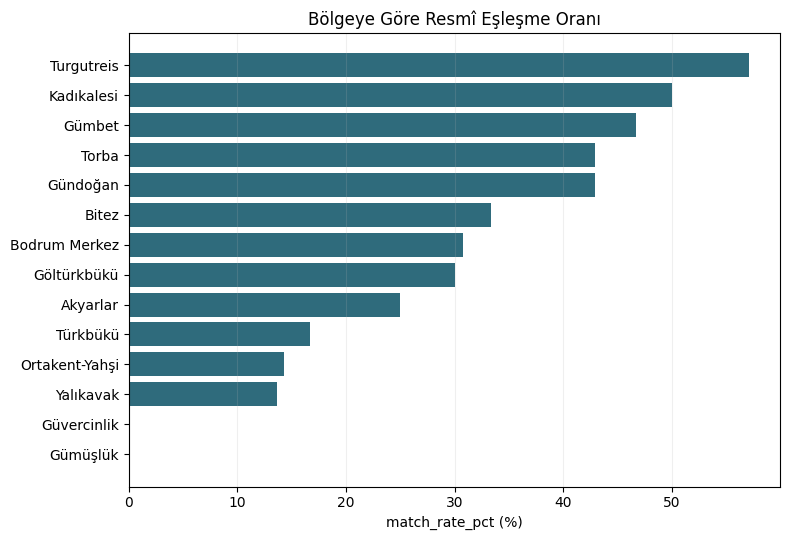

In [20]:
area_coverage = build_area_coverage(enriched)
display(area_coverage)

fig, ax = plt.subplots(figsize=(8, 5.5))
order = area_coverage.sort_values("match_rate_pct")["area"]
ax.barh(order, area_coverage.set_index("area").loc[order, "match_rate_pct"], color="#2F6B7C")
ax.set(title="Bölgeye Göre Resmî Eşleşme Oranı", xlabel="match_rate_pct (%)")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

**Bulgu:** Gümüşlük ve Güvercinlik'te resmî eşleşme oranı **%0** — bu iki bölgede projedeki hiçbir
otel yüksek güvenle resmî kayda bağlanamadı (isim/telefon uyuşmazlığı veya bu bölgelerdeki
otellerin resmî "işletme belgeli tesis" listesinde yer almaması olabilir). En yüksek coverage
Turgutreis (%57) ve Kadıkalesi (%50) gibi küçük örneklemli bölgelerde — tek tük eşleşme küçük
örneklemde oranı hızlı yükseltiyor, bu nedenle yüzdeler mutlak sayılarla (hotel_count) birlikte
okunmalı.

### 16. Yıldız / oda / yatak dağılımı (yalnızca veri kontrolü)

Bu notebook bir EDA notebooku değildir; aşağıdaki tablolar yalnızca zenginleştirilmiş verinin
makul göründüğünü doğrulamak içindir. **Yıldız vs rating, oda sayısı vs rating gibi analizler
kasıtlı olarak yapılmamıştır** — bu, `07_hotel_attributes_analysis.ipynb`'in görevidir.


In [21]:
star_labels = {1.0: "1 yıldız", 2.0: "2 yıldız", 3.0: "3 yıldız", 4.0: "4 yıldız", 5.0: "5 yıldız"}
verified_star_counts = enriched["official_star_rating_verified"].map(star_labels).fillna("Diğer/bilinmiyor (tip yıldız belirtmiyor veya eşleşmedi)")
display(verified_star_counts.value_counts().to_frame("hotel_count"))

print()
print("official_room_count özet (yalnızca eşleşen oteller):")
display(enriched["official_room_count"].describe()[["min", "50%", "max"]])
print()
print("official_bed_count özet (yalnızca eşleşen oteller):")
display(enriched["official_bed_count"].describe()[["min", "50%", "max"]])

,hotel_count
official_star_rating_verified,
Diğer/bilinmiyor (tip yıldız belirtmiyor veya eşleşmedi),141
5 yıldız,21
4 yıldız,17
3 yıldız,10
2 yıldız,3



official_room_count özet (yalnızca eşleşen oteller):


min     12.0
50%     81.5
max    540.0
Name: official_room_count, dtype: float64


official_bed_count özet (yalnızca eşleşen oteller):


min      36.0
50%     179.5
max    1080.0
Name: official_bed_count, dtype: float64

### 17. Çıktıların kaydedilmesi

Tüm rapor tabloları `reports/` altına, zenginleştirilmiş dataset `data/processed/hotels_enriched.csv`
olarak kaydedilir. Ana `hotels_features.csv` ve external CSV bu notebookta hiçbir noktada
değiştirilmedi.


In [22]:
official_conflicts_output = official_conflicts.copy()

outputs = {
    "hotel_attributes_match_summary": match_summary,
    "hotel_attributes_high_confidence_matches": high_confidence_matches,
    "hotel_attributes_manual_review": manual_review,
    "hotel_attributes_unmatched_project_hotels": unmatched_project_hotels,
    "hotel_attributes_unmatched_official_facilities": unmatched_official_facilities,
    "hotel_attributes_official_conflicts": official_conflicts_output,
    "hotel_attributes_match_coverage_by_area": area_coverage,
    "hotels_enriched": enriched,
}
output_paths = save_matching_outputs(outputs, REPORTS_DIR, PROCESSED_DIR)
display(pd.DataFrame([
    {"output": name, "path": str(path.relative_to(PROJECT_ROOT))} for name, path in output_paths.items()
]))

,output,path
0,hotel_attributes_match_summary,reports/hotel_attributes_match_summary.csv
1,hotel_attributes_high_confidence_matches,reports/hotel_attributes_high_confidence_match...
2,hotel_attributes_manual_review,reports/hotel_attributes_manual_review.csv
3,hotel_attributes_unmatched_project_hotels,reports/hotel_attributes_unmatched_project_hot...
4,hotel_attributes_unmatched_official_facilities,reports/hotel_attributes_unmatched_official_fa...
5,hotel_attributes_official_conflicts,reports/hotel_attributes_official_conflicts.csv
6,hotel_attributes_match_coverage_by_area,reports/hotel_attributes_match_coverage_by_are...
7,hotels_enriched,data/processed/hotels_enriched.csv


### 18. Testler

Bu eşleştirme mantığının temel garantileri `tests/test_hotel_matching.py` içinde otomatik test
edilir (gerçek proje verisiyle çalışır):

- 192 proje oteli korunuyor, `hotel_id`/`place_id` benzersiz kalıyor.
- Hiçbir `official_facility_id`, yüksek güvenli eşleşmede birden fazla otele bağlanmıyor.
- `official_star_rating_verified` her zaman 1-5 aralığında.
- `official_room_count` / `official_bed_count` negatif veya sıfır değil.
- Eşleşmeyen otellerde hiçbir resmî kolon uydurulmuyor (tamamı `NaN`).
- Mevcut `official_star_rating` kolonu overwrite edilmiyor.

Çalıştırma: `PYTHONPATH=src python3 -m unittest tests.test_hotel_matching -v`


In [23]:
import io
import unittest

TESTS_DIR = PROJECT_ROOT / "tests"
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

loader = unittest.TestLoader()
suite = loader.loadTestsFromName("test_hotel_matching")
stream = io.StringIO()
runner = unittest.TextTestRunner(stream=stream, verbosity=2)
test_result = runner.run(suite)
print(stream.getvalue())
assert test_result.wasSuccessful(), "hotel_matching testleri başarısız oldu." 

test_existing_official_star_rating_column_not_overwritten (test_hotel_matching.HotelMatchingTests) ... ok
test_no_negative_room_or_bed_counts (test_hotel_matching.HotelMatchingTests) ... ok
test_no_official_facility_linked_to_more_than_one_hotel (test_hotel_matching.HotelMatchingTests) ... ok
test_normalize_phone_strips_country_code_and_leading_zero (test_hotel_matching.HotelMatchingTests) ... ok
test_project_hotel_count_and_keys_preserved (test_hotel_matching.HotelMatchingTests) ... ok
test_unmatched_hotels_have_no_fabricated_official_data (test_hotel_matching.HotelMatchingTests) ... ok
test_verified_star_rating_in_range (test_hotel_matching.HotelMatchingTests) ... ok

----------------------------------------------------------------------
Ran 7 tests in 2.927s

OK



## Eşleştirme Sonuçları ve Sonraki Aşama

**Proje otelleri (192):**

- **52 otel (%27)** `MATCHED_HIGH_CONFIDENCE` — kesin/tekil telefon eşleşmesi ya da neredeyse
  birebir isim + doğrulanmış bölge ile otomatik zenginleştirildi.
- **48 otel (%25)** `REVIEW_REQUIRED` — güçlü ama tek başına yeterli görülmeyen sinyaller
  (ör. yüksek isim benzerliği ama telefon/bölge teyidi yok, ya da bölge çelişkisi) nedeniyle
  manuel incelemeye bırakıldı; `reports/hotel_attributes_manual_review.csv`.
- **92 otel (%48)** `UNMATCHED` — hiçbir katmanda anlamlı bir resmî aday bulunamadı; büyük
  ölçüde küçük apart/pansiyon/villa tipi konaklamalar.

**Resmî kayıtlar (168):**

- **52 kayıt** proje verisine bağlandı (`MATCHED`).
- **108 kayıt** proje örnekleminde karşılığı bulunamadı (`UNMATCHED_OFFICIAL`).
- **8 kayıt** (4 grup) iç çelişki taşıyor (`official_conflict_flag`) — aynı isim/telefon
  paylaşan ama yıldız/tip/oda/yatak bilgisi farklı olan kayıtlar; ayrı raporlandı.

**Zenginleştirme kapsamı (yalnızca yüksek güvenli 52 otel üzerinden):**

- Doğrulanmış yıldız bilgisi olan otel sayısı: **51 / 192 (%26.6)** (52 eşleşmeden 1'inin resmî
  tipi yıldız belirtmiyor, bu kasıtlı olarak boş bırakıldı).
- Oda/yatak kapasitesi olan otel sayısı: **52 / 192 (%27.1)** her ikisi için de.

**En önemli matching sorunları:**

1. **Coğrafi çelişkiler isim/adres eşleşmesini geçersiz kılabiliyor** — "Armonia Holiday
   Village & Spa" örneğinde isim ve adres %100 örtüşse bile resmî kayıttaki bölge etiketi
   projeyle çelişiyor; bu tür kayıtlar bilinçli olarak otomatik merge dışında tutuldu.
2. **Paylaşılan telefon numaraları yanlış yönlendirebilir** — "Mandarin Resort Hotel" ile
   "Mandarin Oriental, Bodrum" aynı resmî telefon numarasına eşleşiyor; yalnızca isim
   benzerliğini de dikkate alan çakışma çözümü doğru tarafı (Mandarin Oriental) korudu.
3. **Kardeş/şube tesisler tek resmî kayda sıkışabiliyor** — "Voyage Torba" / "Voyage Torba
   Private" ve "CACTUS" grubu örneklerinde birden fazla proje/marka aynı santral hattını
   paylaşıyor; bu gruplardan yalnızca en güçlü eşleşme otomatik alındı, diğerleri incelemeye
   bırakıldı.
4. **Resmî coverage bölgeler arası çok dengesiz** — Gümüşlük ve Güvercinlik'te %0 eşleşme
   oranı, bu iki destinasyonda ileride resmî veri zenginleştirmesinin en zayıf halka olacağını
   gösteriyor.

**Sonraki aşama:**

```text
07_hotel_attributes_analysis.ipynb
```

Bu notebookta üretilen `data/processed/hotels_enriched.csv` girdi olarak kullanılacak; yıldız
vs rating, oda sayısı vs rating, fiyat vs yıldız gibi analizler ancak o notebookta yapılacaktır.


### Sonuç

- 192 proje oteli ve 168 resmî tesis kaydı hiçbir kaynak dosya değiştirilmeden ayrı ayrı audit
  edildi; ham mantık hatası (yıldız/oda/yatak aralığı, duplicate ID) bulunmadı.
- Resmî tesis içindeki 8 olası duplicate/çelişki otomatik seçim yapılmadan flag'lendi.
- Katmanlı eşleştirme (telefon → kesin isim → fuzzy isim + destek sinyalleri) ve açıklanabilir
  ağırlıklı skor ile yalnızca 52 otel otomatik zenginleştirildi; 48 otel manuel incelemeye,
  92 otel `UNMATCHED` olarak bırakıldı — hiçbir veri uydurulmadı.
- Gerçek skor dağılımı incelenerek (0.80-0.95 arası doğal boşluk) ve üç somut sınır vakası
  (Armonia, Mandarin, Voyage Torba) üzerinden eşikler konservatif biçimde kalibre edildi.
- `data/processed/hotels_enriched.csv` ve 7 rapor `reports/` altına kaydedildi; mevcut
  `hotels_features.csv`, external CSV ve önceki notebooklar değişmeden kaldı.
- `tests/test_hotel_matching.py` içindeki 7 test bu garantileri otomatik doğruluyor.
- Sonraki aşama: `07_hotel_attributes_analysis.ipynb` — yıldız/oda/fiyat/rating ilişkilerinin
  analiz edileceği notebook.
